In [1]:
# Download the Census data from the Parsons GitHub repository
from parsons import GitHub

github = GitHub()
dummy_data = github.download_table('move-coop/parsons', 'docs/quickstart.csv')
assert dummy_data.num_rows == 1000  # Check that we got all 1,000 people

# Filter down to people with cell phones
people_with_cell_phones = dummy_data.select_rows(lambda row: row['is_cell'] == 'true')
assert people_with_cell_phones.num_rows == 498  # Check that we filtered down to our 498 people

# Extract only the columns we need (first name, last name, phone number)
people_with_cell_phones = people_with_cell_phones.cut('first_name', 'last_name', 'phone_number')
assert people_with_cell_phones.columns == ['first_name', 'last_name', 'phone_number']  # Check columns

# Output the list to a local CSV file
filename = people_with_cell_phones.to_csv('/Users/kenhartman/Documents/van/dummy_data.csv')  # filename will be the path to the local CSV file


/var/folders/z5/dzs2wvw11fl5s571q4b97thh0000gn/T/ipykernel_84994/24168391.py:2: RuntimeWarning: The behavior of 'pip install parsons' has changed so only core dependencies are installed.Learn more: https://www.parsonsproject.org/pub/improving-the-parsons-installation-experience
  from parsons import GitHub
github INFO Downloading docs/quickstart.csv from move-coop/parsons, branch main to /var/folders/z5/dzs2wvw11fl5s571q4b97thh0000gn/T/inle3sbk
github INFO Downloaded docs/quickstart.csv to /var/folders/z5/dzs2wvw11fl5s571q4b97thh0000gn/T/inle3sbk


In [2]:
from parsons import VAN
van = VAN(db='MyVoters')
ac = van.get_activist_codes()
ac.to_csv('/Users/kenhartman/Documents/van/my_activist_codes.csv')

KeyError: 'No VAN_API_KEY found. Store as environment variable or pass as an argument.'

In [44]:
import geopandas as gpd
import pandas as pd

CRS = "EPSG:2278"

precincts = gpd.read_file('/Users/kenhartman/Documents/van/precincts.geojson').to_crs(CRS)
print("precincts: ", precincts.head())
sboe = gpd.read_file('/Users/kenhartman/Documents/van/sboe.geojson').to_crs(CRS)
print("sboe: ", sboe.head())
house = gpd.read_file('/Users/kenhartman/Documents/van/house.geojson').to_crs(CRS)
print("house: ", house.head())
senate = gpd.read_file('/Users/kenhartman/Documents/van/senate.geojson').to_crs(CRS)
print("senate: ", senate.head())
congress = gpd.read_file('/Users/kenhartman/Documents/van/congress.geojson').to_crs(CRS)
print("congress:", congress.head())

precincts:     OBJECTID  NAME   ShapeSTArea  ShapeSTLength  \
0         1  1066  1.959649e+08   85065.064879   
1         2  1067  1.037444e+09  173926.544405   
2         3  1063  4.697159e+08  123224.030460   
3         4  1065  5.424976e+08  125473.640950   
4         5  1095  1.715917e+08   53841.460066   

                                            geometry  
0  POLYGON ((2062886.841 13643514.859, 2062829.64...  
1  POLYGON ((2073253.407 13666984.708, 2073247.34...  
2  POLYGON ((2091455.581 13650086.46, 2091455.441...  
3  POLYGON ((2087261.417 13638873.397, 2087256.74...  
4  POLYGON ((2076640.621 13690576.881, 2076399.61...  
sboe:     OBJECTID  District   Shape__Area  Shape__Length  \
0         1         1  1.752546e+12   1.110755e+07   
1         2         2  4.244796e+11   5.042357e+06   
2         3         3  4.340538e+11   5.127981e+06   
3         4         4  1.492870e+10   1.076416e+06   
4         5         5  1.281826e+11   2.056797e+06   

                         

In [45]:
plans = {
    "congress": (congress, "District"),
    "senate":   (senate,   "District"),
    "house":    (house,    "District"),
    "sboe":     (sboe,     "District"),
}

pct_id = "NAME"

precincts["geometry"] = precincts.geometry.buffer(0)

for name, (gdf, _) in plans.items():
    gdf["geometry"] = gdf.geometry.buffer(0)


sliver_fraction = 0.01

split_results = {}

for plan_name, (plan_gdf, dist_col) in plans.items():
    print(f"\nProcessing {plan_name}...")

    # Intersect precincts with district plan
    intersected = gpd.overlay(precincts[[pct_id, "geometry"]], plan_gdf[[dist_col, "geometry"]], how="intersection")
    intersected["frag_area"] = intersected.geometry.area

    # Attach precinct total area for sliver filter
    pct_areas = precincts.set_index(pct_id).geometry.area
    intersected["pct_area"] = intersected[pct_id].map(pct_areas)
    intersected["frag_frac"] = intersected["frag_area"] / intersected["pct_area"]

    # Drop sliver fragments
    real_frags = intersected[intersected["frag_frac"] >= sliver_fraction]

    # Count distinct districts per precinct
    district_counts = (
        real_frags.groupby(pct_id)[dist_col]
        .nunique()
        .rename(f"n_districts_{plan_name}")
    )
    district_counts_0 = (
        intersected.groupby(pct_id)[dist_col]
        .nunique()
        .rename(f"n_districts_{plan_name}")
    )
    split_results[plan_name] = district_counts

    n_split = (district_counts > 1).sum()
    n_total = len(precincts)
    print(f"  {n_split} of {n_total} precincts split ({100*n_split/n_total:.1f}%)")


Processing congress...
  3 of 806 precincts split (0.4%)

Processing senate...
  4 of 806 precincts split (0.5%)

Processing house...
  5 of 806 precincts split (0.6%)

Processing sboe...
  2 of 806 precincts split (0.2%)


In [47]:
# Inside or after the loop — build a comparison frame per plan
comparison = pd.concat([
    district_counts_0.rename("with_slivers"),
    district_counts.rename("without_slivers"),
], axis=1).fillna(1).astype(int)

comparison["diff"] = comparison["with_slivers"] - comparison["without_slivers"]
comparison["changed"] = comparison["diff"] > 0

print(f"\n=== {plan_name} sliver impact ===")
print(f"Precincts affected by sliver filter: {comparison['changed'].sum()}")
print(f"Total slivers removed: {comparison['diff'].sum()}")

# Show only the precincts where filtering changed the count
changed_only = comparison[comparison["changed"]].sort_values("diff", ascending=False)
print(f"\nPrecincts where filtering changed the split count:")
print(changed_only)

# Also useful: precincts that look split WITH slivers but aren't actually split
false_splits = comparison[
    (comparison["with_slivers"] > 1) & (comparison["without_slivers"] == 1)
]
print(f"\nFalse-positive splits removed by filter: {len(false_splits)}")




=== sboe sliver impact ===
Precincts affected by sliver filter: 103
Total slivers removed: 105

Precincts where filtering changed the split count:
      with_slivers  without_slivers  diff  changed
NAME                                              
3097             3                1     2     True
3005             3                1     2     True
1009             2                1     1     True
3034             2                1     1     True
3093             2                1     1     True
...            ...              ...   ...      ...
2086             2                1     1     True
2084             2                1     1     True
2078             2                1     1     True
2076             2                1     1     True
4225             2                1     1     True

[103 rows x 4 columns]

False-positive splits removed by filter: 103


In [48]:
sliver_diagnostics = {}

for plan_name, (plan_gdf, dist_col) in plans.items():
    intersected = gpd.overlay(
        precincts[[pct_id, "geometry"]],
        plan_gdf[[dist_col, "geometry"]],
        how="intersection",
    )
    intersected["frag_area"] = intersected.geometry.area
    pct_areas = precincts.set_index(pct_id).geometry.area
    intersected["pct_area"] = intersected[pct_id].map(pct_areas)
    intersected["frag_frac"] = intersected["frag_area"] / intersected["pct_area"]

    with_slivers = intersected.groupby(pct_id)[dist_col].nunique()
    without_slivers = (intersected[intersected["frag_frac"] >= sliver_fraction]
                       .groupby(pct_id)[dist_col].nunique())

    comp = pd.concat([
        with_slivers.rename("with_slivers"),
        without_slivers.rename("without_slivers"),
    ], axis=1).fillna(1).astype(int)
    comp["diff"] = comp["with_slivers"] - comp["without_slivers"]
    sliver_diagnostics[plan_name] = comp

    n_changed = (comp["diff"] > 0).sum()
    n_slivers = comp["diff"].sum()
    print(f"{plan_name:10s}: {n_changed:4d} precincts affected, "
          f"{n_slivers:4d} slivers removed")

congress  :  312 precincts affected,  325 slivers removed
senate    :  290 precincts affected,  301 slivers removed
house     :  487 precincts affected,  566 slivers removed
sboe      :  103 precincts affected,  105 slivers removed


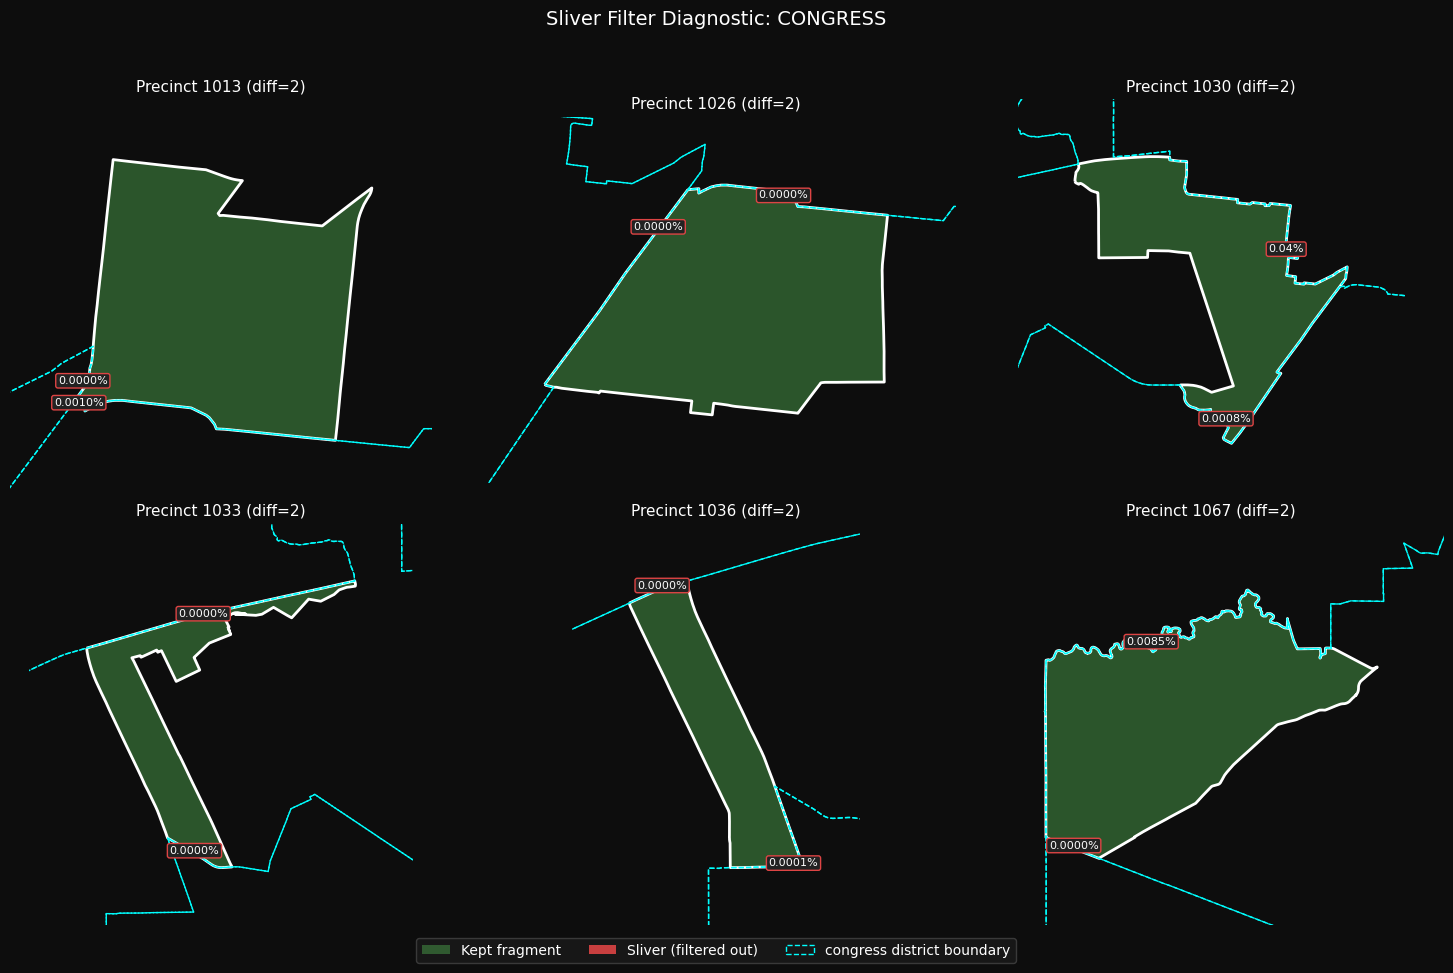

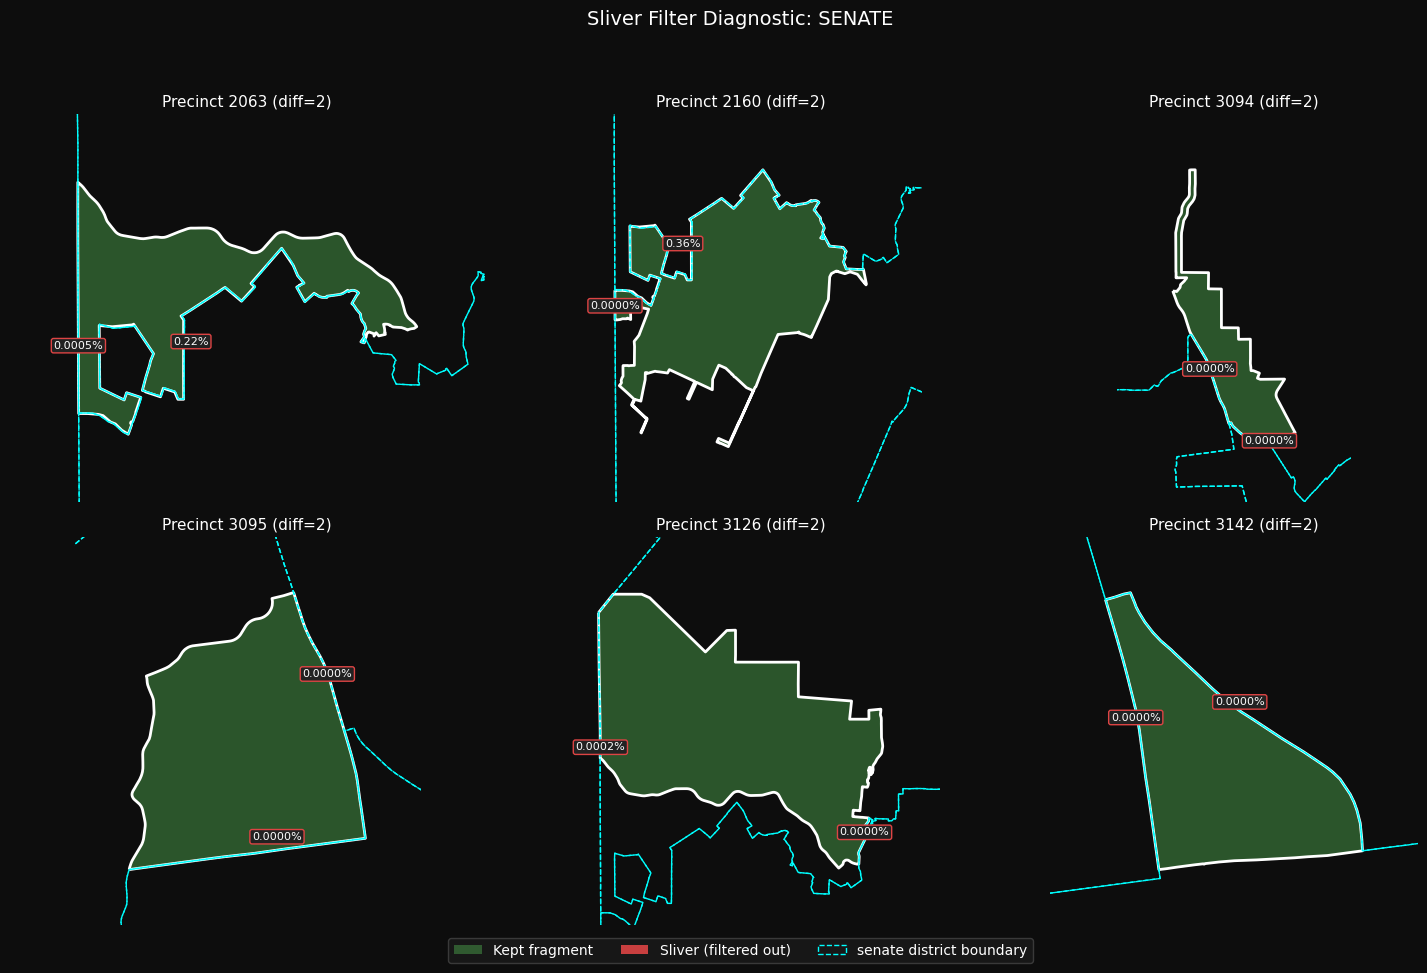

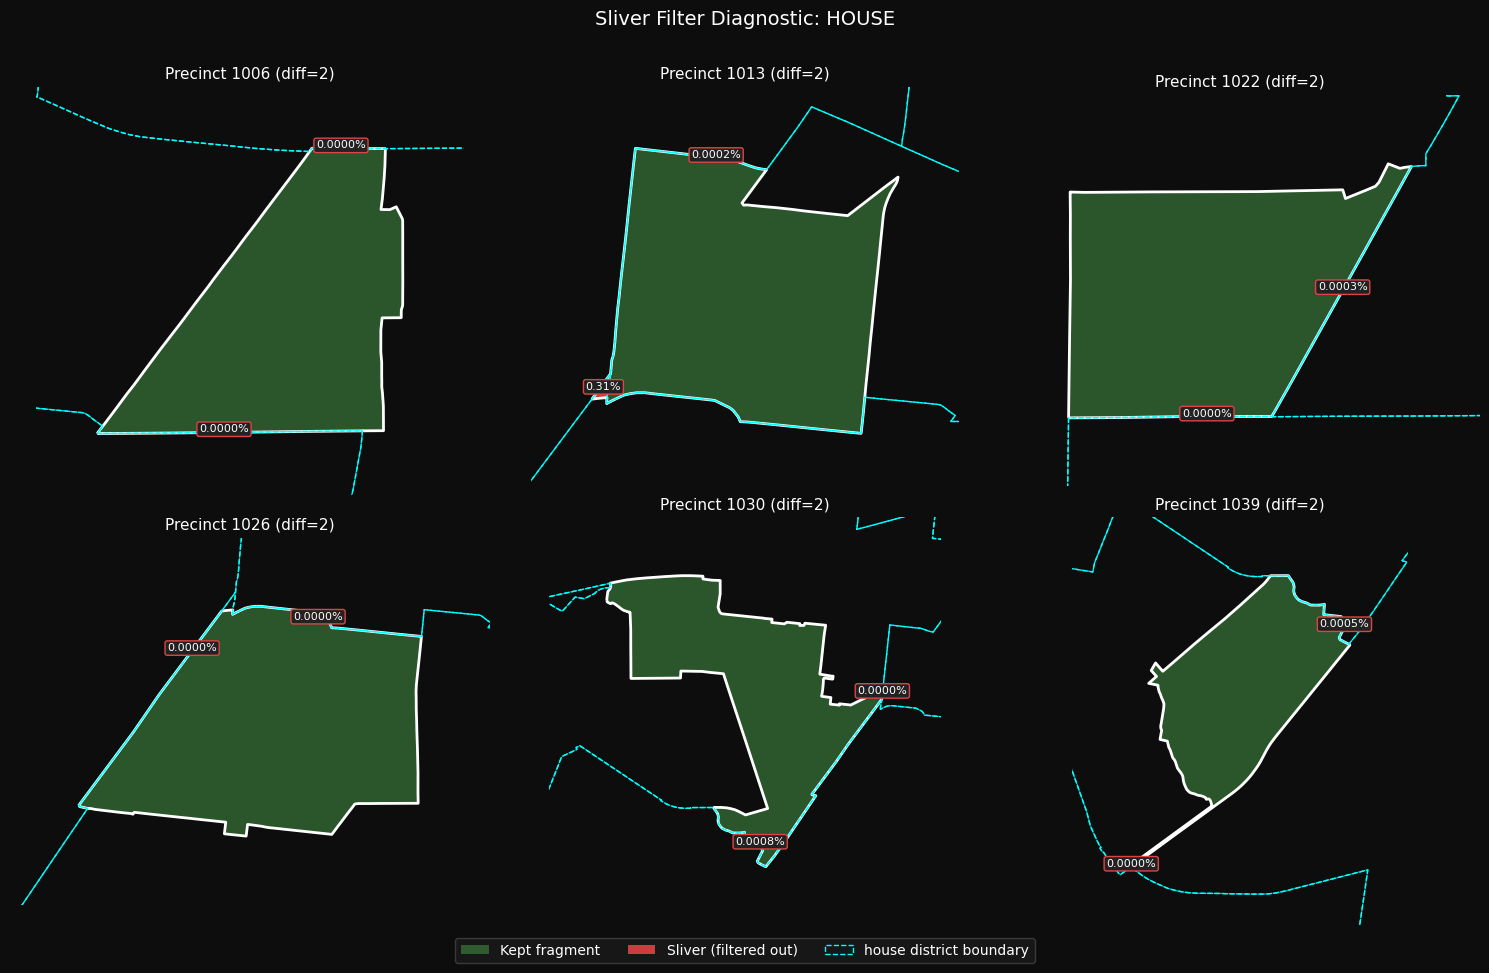

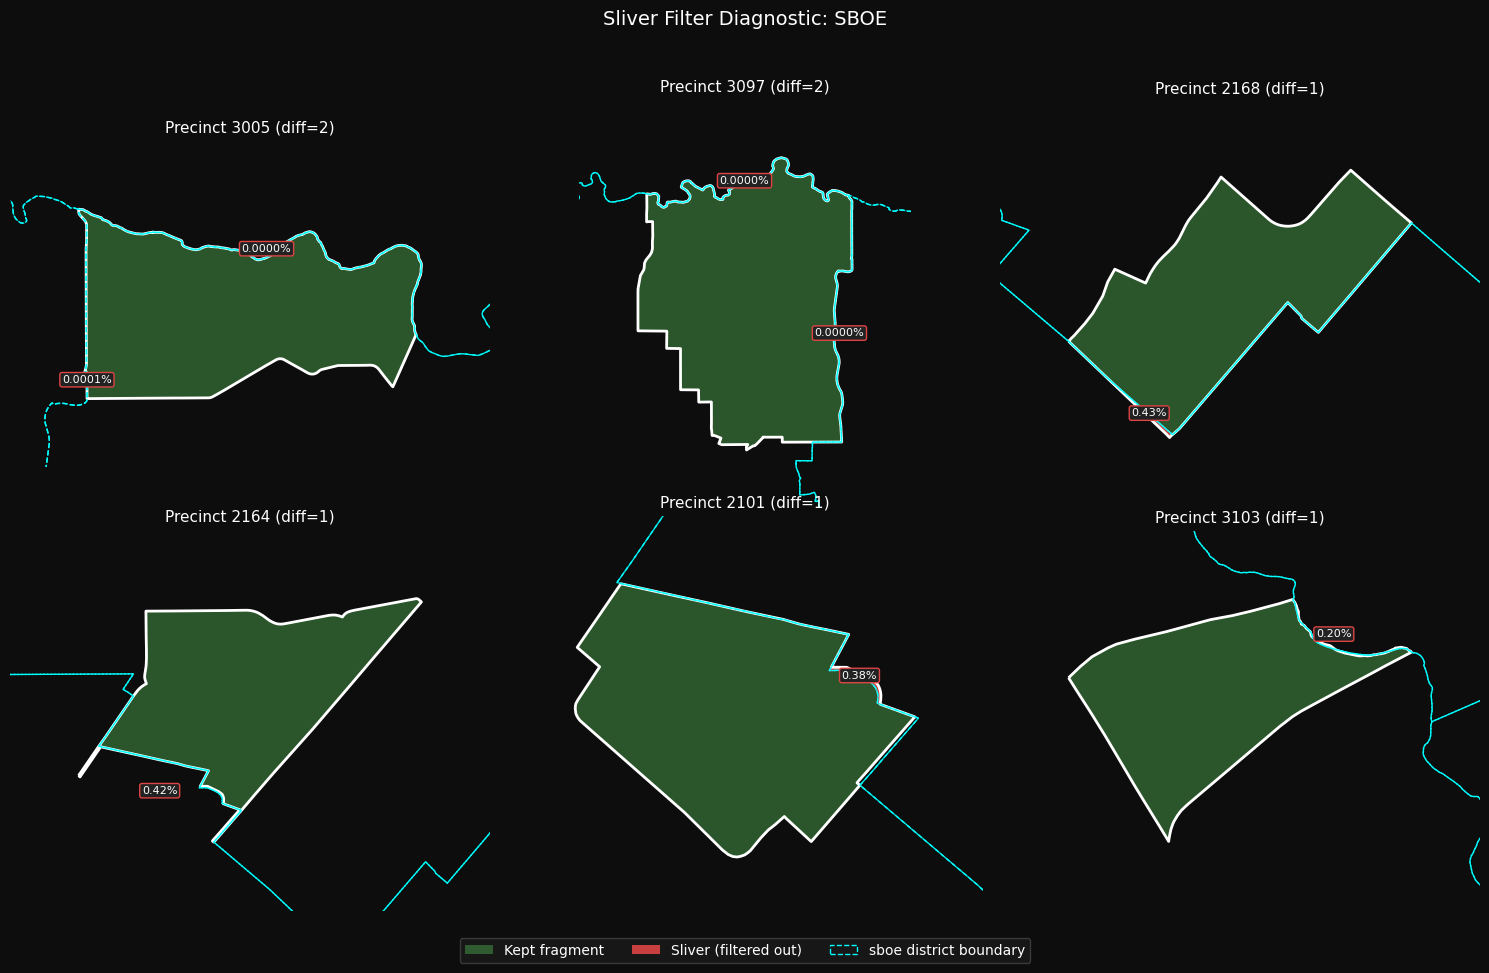

In [49]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Loop through all four plans
for plan_name, (plan_gdf, dist_col) in plans.items():
    diag = sliver_diagnostics[plan_name]

    # Pick precincts to inspect: worst cases first, then largest-sliver cases
    diff_high = diag[diag["diff"] >= 2].index.tolist()

    # Find precincts with the largest filtered slivers (closest to threshold)
    intersected = gpd.overlay(
        precincts[[pct_id, "geometry"]],
        plan_gdf[[dist_col, "geometry"]],
        how="intersection",
    )
    intersected["frag_area"] = intersected.geometry.area
    pct_areas = precincts.set_index(pct_id).geometry.area
    intersected["pct_area"] = intersected[pct_id].map(pct_areas)
    intersected["frag_frac"] = intersected["frag_area"] / intersected["pct_area"]

    filtered_slivers = intersected[
        (intersected["frag_frac"] < sliver_fraction) &
        (intersected["frag_frac"] > 0)
    ].sort_values("frag_frac", ascending=False)

    suspect = filtered_slivers[pct_id].drop_duplicates().tolist()

    # Combine: high-diff cases + largest slivers, deduplicated, capped at 6
    to_inspect = list(dict.fromkeys(diff_high + suspect))[:6]

    if len(to_inspect) == 0:
        print(f"\n{plan_name}: no precincts to inspect (no slivers filtered)")
        continue

    # Pad if fewer than 6
    n_panels = len(to_inspect)
    rows = 2 if n_panels > 3 else 1
    cols = min(3, n_panels)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows),
                             facecolor="#0d0d0d", squeeze=False)
    axes = axes.flatten()

    for i, pid in enumerate(to_inspect):
        ax = axes[i]
        ax.set_facecolor("#0d0d0d")

        pct = precincts[precincts[pct_id] == pid]
        if len(pct) == 0:
            ax.set_title(f"{pid} not found", color="white")
            ax.set_axis_off()
            continue

        pct_inter = gpd.overlay(
            pct[[pct_id, "geometry"]],
            plan_gdf[[dist_col, "geometry"]],
            how="intersection",
        )
        pct_inter["frag_area"] = pct_inter.geometry.area
        pct_inter["pct_area"] = pct.geometry.area.iloc[0]
        pct_inter["frag_frac"] = pct_inter["frag_area"] / pct_inter["pct_area"]
        pct_inter["kept"] = pct_inter["frag_frac"] >= sliver_fraction

        pct.boundary.plot(ax=ax, color="white", linewidth=2, zorder=3)

        kept = pct_inter[pct_inter["kept"]]
        slivers = pct_inter[~pct_inter["kept"]]

        if len(kept) > 0:
            kept.plot(ax=ax, color="#4a9d4a", alpha=0.5, edgecolor="#4a9d4a",
                      linewidth=0.5, zorder=1)
        if len(slivers) > 0:
            slivers.plot(ax=ax, color="#d44", alpha=0.9, edgecolor="#d44",
                         linewidth=1, zorder=2)

        bounds = pct.total_bounds
        pad = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 0.2
        plan_nearby = plan_gdf.cx[bounds[0]-pad:bounds[2]+pad,
                                  bounds[1]-pad:bounds[3]+pad]
        plan_nearby.boundary.plot(ax=ax, color="cyan", linewidth=1,
                                  linestyle="--", zorder=4)

        ax.set_xlim(bounds[0]-pad, bounds[2]+pad)
        ax.set_ylim(bounds[1]-pad, bounds[3]+pad)

        for _, row in slivers.iterrows():
            c = row.geometry.centroid
            # Better precision label
            frac_pct = row['frag_frac'] * 100
            label = f"{frac_pct:.4f}%" if frac_pct < 0.01 else f"{frac_pct:.2f}%"
            ax.annotate(label, xy=(c.x, c.y), color="white", fontsize=8,
                        ha="center", zorder=5,
                        bbox=dict(boxstyle="round,pad=0.2",
                                  facecolor="#222", edgecolor="#d44"))

        diff_val = diag.loc[pid, "diff"]
        ax.set_title(f"Precinct {pid} (diff={diff_val})",
                     color="white", fontsize=11)
        ax.set_axis_off()

    # Hide unused axes
    for i in range(n_panels, len(axes)):
        axes[i].set_axis_off()

    legend_elements = [
        Patch(facecolor="#4a9d4a", alpha=0.5, label="Kept fragment"),
        Patch(facecolor="#d44", alpha=0.9, label="Sliver (filtered out)"),
        Patch(facecolor="none", edgecolor="cyan", linestyle="--",
              label=f"{plan_name} district boundary"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3,
               facecolor="#1a1a1a", edgecolor="#444", labelcolor="white",
               bbox_to_anchor=(0.5, 0.02))

    fig.suptitle(f"Sliver Filter Diagnostic: {plan_name.upper()}",
                 color="white", fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()

In [7]:
intersected.to_file('/Users/kenhartman/Documents/van/test_intersect.gpkg')

In [50]:
# ---- Combine into one precinct-level table ----
splits_df = pd.concat(split_results.values(), axis=1).fillna(1).astype(int)
splits_df["split_count"] = (splits_df > 1).sum(axis=1)  # 0–4 layers split

# Attach back to precincts geometry
precincts_out = precincts.merge(splits_df, left_on=pct_id, right_index=True, how="left")
precincts_out["split_count"] = precincts_out["split_count"].fillna(0).astype(int)
# ---- Summary stats ----
print("\n=== Summary ===")
print(f"Total Bexar precincts: {len(precincts_out)}")
for plan_name in plans:
    n_split = (precincts_out[f"n_districts_{plan_name}"] > 1).sum()
    print(f"  Split by {plan_name:10s}: {n_split} ({100*n_split/len(precincts_out):.1f}%)")
print(f"Split by ≥1 layer:  {(precincts_out['split_count'] >= 1).sum()}")
print(f"Split by ≥2 layers: {(precincts_out['split_count'] >= 2).sum()}")
print(f"Split by all 4:     {(precincts_out['split_count'] == 4).sum()}")

precincts_out.to_file("/Users/kenhartman/Documents/van/Bexar_County_precincts_with_splits.gpkg")


=== Summary ===
Total Bexar precincts: 806
  Split by congress  : 3 (0.4%)
  Split by senate    : 4 (0.5%)
  Split by house     : 5 (0.6%)
  Split by sboe      : 2 (0.2%)
Split by ≥1 layer:  14
Split by ≥2 layers: 0
Split by all 4:     0


In [35]:
precincts_out.columns

Index(['OBJECTID', 'NAME', 'ShapeSTArea', 'ShapeSTLength', 'geometry',
       'n_districts_congress', 'n_districts_senate', 'n_districts_house',
       'n_districts_sboe', 'split_count'],
      dtype='str')

In [51]:
import geopandas as gpd
from pathlib import Path

output = Path("/Users/kenhartman/Documents/van/output/data")
# Reproject everything to EPSG:4326 for web display
WEB_CRS = 4326
bexar_boundary = gpd.read_file('/Users/kenhartman/Documents/van/Bexar_County_Boundary.geojson')
# Precincts with all the analytical fields
precincts_export = precincts_out.to_crs(WEB_CRS).copy()
precincts_export = precincts_export.rename(columns={
    "NAME": "precinct"
})

# Drop unneeded columns to keep file size down
keep_cols = ['precinct','n_districts_congress', 'n_districts_senate', 'n_districts_house',
       'n_districts_sboe', 'split_count', 'geometry']
precincts_export = precincts_export[keep_cols]

# Simplify geometries to reduce file size (10m tolerance is plenty for web)
precincts_export["geometry"] = (
    precincts_export.to_crs(2278).geometry.simplify(10).to_crs(WEB_CRS)
)

precincts_export.to_file(output / "precincts.geojson", driver="GeoJSON",
                          coordinate_precision=6)

# Same for each district plan
for name, gdf in [("congress", congress), ("senate", senate),
                  ("house", house), ("sboe", sboe)]:
    out = gdf.to_crs(2278).copy()
    out["geometry"] = out.geometry.simplify(20)  # districts can be more simplified
    out = out.to_crs(WEB_CRS)
    # Clip to Bexar (assuming you have a bexar boundary)
    out = gpd.overlay(out, bexar_boundary, how="intersection")
    out.to_file(output / f"{name}.geojson", driver="GeoJSON", coordinate_precision=6)

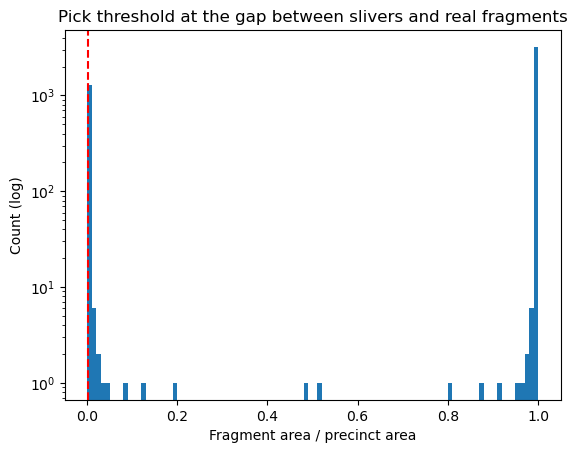

In [5]:
# Distribution of fragment fractions — helps pick the right sliver cutoff
import numpy as np
import matplotlib.pyplot as plt
all_fracs = []
for plan_name, (plan_gdf, dist_col) in plans.items():
    inter = gpd.overlay(precincts[[pct_id, "geometry"]],
                        plan_gdf[[dist_col, "geometry"]],
                        how="intersection")
    pct_areas = precincts.set_index(pct_id).geometry.area
    fracs = inter.geometry.area / inter[pct_id].map(pct_areas)
    all_fracs.extend(fracs.tolist())

plt.figure()
plt.hist(np.clip(all_fracs, 0, 1), bins=100)
plt.yscale("log")
plt.xlabel("Fragment area / precinct area")
plt.ylabel("Count (log)")
plt.axvline(sliver_fraction, color="red", linestyle="--")
plt.title("Pick threshold at the gap between slivers and real fragments")
plt.show()

In [6]:
# Compound-split precincts: the 17 cut by 2+ layers
compound = precincts_out[precincts_out["split_count"] >= 2].copy()
compound = compound.sort_values("split_count", ascending=False)

print(f"\n=== {len(compound)} compound-split precincts ===\n")
cols = [pct_id, "n_districts_congress", "n_districts_senate",
        "n_districts_house", "n_districts_sboe", "split_count"]
print(compound[cols].to_string(index=False))

# Which layer combinations show up?
print("\n=== Layer-combination patterns ===")
def split_pattern(row):
    layers = []
    if row["n_districts_congress"] > 1: layers.append("C")
    if row["n_districts_senate"]   > 1: layers.append("S")
    if row["n_districts_house"]    > 1: layers.append("H")
    if row["n_districts_sboe"]     > 1: layers.append("E")
    return "+".join(layers)

compound["pattern"] = compound.apply(split_pattern, axis=1)
print(compound["pattern"].value_counts())

# Geographic clustering check
compound["centroid_x"] = compound.geometry.centroid.x
compound["centroid_y"] = compound.geometry.centroid.y
print("\nCentroid range (m, in EPSG:6584):")
print(f"  X: {compound['centroid_x'].min():.0f} to {compound['centroid_x'].max():.0f}")
print(f"  Y: {compound['centroid_y'].min():.0f} to {compound['centroid_y'].max():.0f}")


=== 353 compound-split precincts ===

NAME  n_districts_congress  n_districts_senate  n_districts_house  n_districts_sboe  split_count
1066                     2                   2                  2                 2            4
1069                     2                   2                  2                 2            4
2187                     3                   2                  3                 2            4
2088                     2                   2                  2                 2            4
2098                     3                   2                  3                 2            4
2076                     2                   2                  2                 2            4
1110                     2                   2                  2                 2            4
3103                     2                   2                  3                 2            4
1067                     3                   2                  4                 2     

In [23]:


# Look for precincts that share both a pattern AND touch each other
from shapely.ops import unary_union

# Group adjacent precincts that share a split pattern — find the corridors
compound = precincts_out[precincts_out["split_count"] >= 2].copy()

for pattern, group in compound.groupby(compound.apply(
    lambda r: (r["n_districts_congress"], r["n_districts_senate"],
               r["n_districts_house"], r["n_districts_sboe"]), axis=1)):
    if len(group) >= 2:
        # Are any in this group spatially adjacent?
        for i, row_i in group.iterrows():
            neighbors = group[group.geometry.touches(row_i.geometry)]
            if len(neighbors) > 0:
                print(f"Pattern {pattern}: precinct {row_i[pct_id]} touches "
                      f"{list(neighbors[pct_id])}")

Pattern (2, 2, 2, 1): precinct 4067 touches ['4197']
Pattern (2, 2, 2, 1): precinct 4197 touches ['4067']


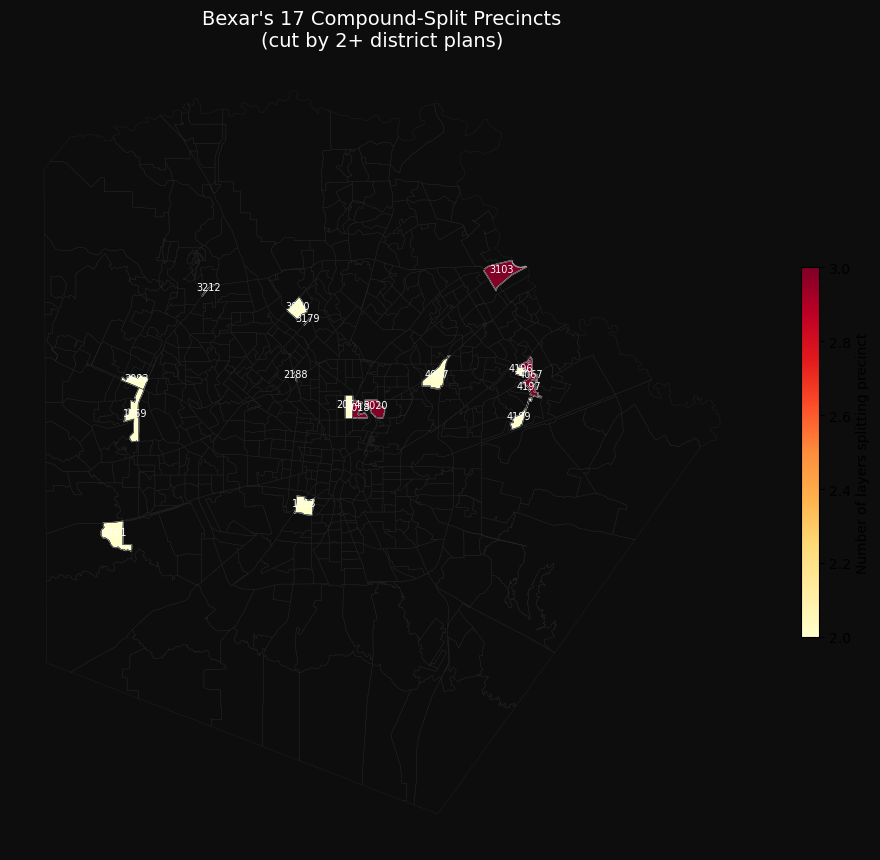

In [24]:
fig, ax = plt.subplots(figsize=(12, 12), facecolor="#0d0d0d")
ax.set_facecolor("#0d0d0d")

# Faint outlines of all precincts for context
precincts_out.boundary.plot(ax=ax, color="#222", linewidth=0.3)

# Highlight the 17 compound splits, colored by how many layers split them
compound.plot(
    column="split_count",
    cmap="YlOrRd",
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Number of layers splitting precinct",
                 "shrink": 0.4},
)

# Label each with its precinct number
for _, row in compound.iterrows():
    ax.annotate(row[pct_id],
                xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                color="white", fontsize=7, ha="center")

ax.set_title("Bexar's 17 Compound-Split Precincts\n"
             "(cut by 2+ district plans)", color="white", fontsize=14)
ax.set_axis_off()
plt.savefig("/Users/kenhartman/Documents/van/bexar_compound_splits.png", dpi=200, bbox_inches="tight",
            facecolor="#0d0d0d")

In [28]:
eresults = gpd.read_file('/Users/kenhartman/Documents/van/Bexar_2024_Presidential/Bexar_2024_Presidential.shp')
eresults["Total_Vote"] = (eresults["Rep_Tot"] + eresults["Dem_Tot"] + eresults["Lib_Tot"] + eresults["Grn_Tot"])
eresults["Turnout_RV"] = eresults["Total_Vote"] / eresults["RegVotrs"]
eresults["Dem_2party"] = (eresults["Dem_Tot"] / (eresults["Dem_Tot"] + eresults["Rep_Tot"]))
eresults["Dem_of_Reg"] = eresults["Dem_Tot"] / eresults["RegVotrs"]

eresults.to_file('/Users/kenhartman/Documents/van/Dpercent_turnout.gpkg')
